GROUP NUMBER: 3

GROUP MEMBER: A.HEMANT KUMAAR, JACK LICHWA , PRITHIKA K


# **PIT STOP ANALYSIS PROJECT**

## **PROJECT BACKGROUND**

Formula 1 (F1) is the pinnacle of motorsport, combining elite driver skill with cutting-edge engineering. A critical and often race-deciding element of F1 strategy is the **pit stop**  a brief pause in which a team changes tires, makes aerodynamic adjustments, or responds to race incidents. The duration of a pit stop, even down to fractions of a second, can determine whether a driver retains or loses a podium position.

For top-finishing drivers (those who finish in the top 3), pit stop strategy is especially high-stakes. A slow stop can cost a driver a podium; an efficiently timed stop can vault them ahead of a competitor. Understanding what factors influence the **maximum pit stop duration** experienced by top 3 finishers has implications for race engineering, team strategy optimization, and performance analytics.

This study investigates whether historical race data, tire information, and race conditions can be used to predict the maximum pit stop duration among the top three drivers in a Formula 1 race. Can the maximum pit stop duration for the top 3 drivers in a Formula 1 race be predicted using race context and historical performance data?

## **DATASET**

**Source**: All datasets come from Kaggle: “Formula 1 Race Data” by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

**Key Variable**:
At this stage, we are exploring all variables from the pit stops, races, circuits, drivers, constructors, lap times, qualifying, and results datasets. Final selection of key predictor variables will be based on further analysis and exploratory data analysis (EDA), including correlations, distributions, and relevance to pit stop duration.

**Data Type**: The datasets include a mix of numeric, categorical, ordinal, and datetime variables:

- Numeric: milliseconds, lap, round, year, alt, points, positionOrder
- Categorical: driverId, surname, constructorId, constructor name, circuitId, location, country, status
- Ordinal: stop (pit stop sequence), grid position, and finishing positions
- Datetime: race dates (races.date) and driver birth dates (drivers.dob)

These variables provide the foundation for preprocessing and exploratory analysis to identify potential predictors for pit stop duration.

## LAB 2

### **SETUP AND DATA LOADING**

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

print('Libraries loaded.')

Libraries loaded.


In [78]:
f1_top3_race_regression_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_top3_pitstop_regression_data.csv')
f1_driver_classification_df = pd.read_csv('https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS/refs/heads/main/data/f1_driver_classification_data.csv')

print('Regression dataset:', f1_top3_race_regression_df.shape)
print('Classification dataset:', f1_driver_classification_df.shape)




Regression dataset: (446, 51)
Classification dataset: (5970, 17)


### **Lab 2 (JACK)**

REGRESSION PROBLEM : Predict total pit stops for the winner.


In [79]:
df_pit_stop_cleaned = f1_top3_race_regression_df.copy()

print('Shape:', df_pit_stop_cleaned.shape)
display(df_pit_stop_cleaned.head())


Shape: (446, 51)


,race_year,race_circuit,race_country,race_altitude_m,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,top3_avg_laps_completed,...,pos3_avg_laps_before_pit_stop,pos3_laps_completed,pos3_pit_stops_avg_duration_s,pos3_pit_stops_count,pos3_pit_stops_max_duration_s,pos3_pit_stops_min_duration_s,pos3_quali_lap_time_s,pos3_qualifying_position,pos3_race_start_position,pos3_team
0,2003,Circuit Gilles Villeneuve,Canada,13,32.485,31.440500,30.229,6.0,33.166667,70.0,...,32.000000,70,31.6265,2.0,32.110,31.143,75.923,2.0,2.0,Williams
1,2003,Nürburgring,Germany,578,33.339,32.821833,32.103,6.0,29.000000,60.0,...,27.000000,60,33.1790,2.0,33.339,33.019,91.780,5.0,5.0,Ferrari
2,2003,Circuit de Nevers Magny-Cours,France,228,23.606,20.948333,19.642,9.0,34.333333,70.0,...,34.666667,70,20.5230,3.0,20.712,20.325,75.480,3.0,3.0,Ferrari
3,2003,Silverstone Circuit,UK,153,41.882,35.278167,32.401,6.0,24.666667,60.0,...,23.500000,60,33.7925,2.0,34.107,33.478,81.695,3.0,3.0,McLaren
4,2003,Hockenheimring,Germany,103,31.207,29.728444,27.638,7.0,29.777778,67.0,...,26.000000,67,30.4770,2.0,31.207,29.747,75.679,4.0,4.0,Renault


##### Problem

Can the total number of pit stops for the race winner in a Formula 1 Grand Prix be predicted using historical race context and circuit characteristics?

Response variable and predictors:
- Target variable: `total_pit_stops_winner`
- Candidate predictors:
  - Race context: `race_year`, `race_circuit`, `race_country`, `race_altitude_m`
  - Pit behavior (all drivers): `race_pit_stops_count`, `race_avg_laps_before_pit_stop`, `race_pit_stops_max_duration_s`, `race_pit_stops_avg_duration_s`, `race_pit_stops_min_duration_s`
  - Per-finisher features: `pos1_pit_stops_count`, `pos1_qualifying_position`, `pos1_quali_lap_time_s`, `pos1_points`, `pos1_laps_completed`, etc.


##### Data Preparation

In [80]:
df = df_pit_stop_cleaned.dropna(subset=['pos1_pit_stops_count']).copy()


In [81]:
y = df['pos1_pit_stops_count']
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 446 entries, 0 to 445
Series name: pos1_pit_stops_count
Non-Null Count  Dtype  
--------------  -----  
446 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

y = df['pos1_pit_stops_count']
X = df.drop('pos1_pit_stops_count', axis=1)



# Encode non-numeric
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Bagging
bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)
bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

##### Evaluate


In [83]:
feature_names = np.array(X.columns)

def top_features(model, k=10):
    imps = model.feature_importances_
    idx = np.argsort(imps)[::-1][:k]
    return pd.DataFrame({
        "feature": feature_names[idx],
        "importance": imps[idx]
    })

top_rf  = top_features(rf_model)
top_gb  = top_features(gb_model)
top_xgb = top_features(xgb_model)

print("=== Random Forest: Top Features ===")
display(top_rf)

print("\n=== Gradient Boosting: Top Features ===")
display(top_gb)

print("\n=== XGBoost: Top Features ===")
display(top_xgb)


=== Random Forest: Top Features ===


,feature,importance
0,top3_pit_stops_count,0.443418
1,top3_avg_pit_stops_count,0.427739
2,race_pit_stops_count,0.011100
3,pos3_qualifying_position,0.009201
4,pos1_avg_laps_before_pit_stop,0.008786
5,top3_avg_race_start_position,0.004752
6,pos2_avg_laps_before_pit_stop,0.004442
7,pos3_pit_stops_count,0.003973
8,race_pit_stops_max_duration_s,0.003118
9,race_pit_stops_min_duration_s,0.003089



=== Gradient Boosting: Top Features ===


,feature,importance
0,top3_avg_pit_stops_count,0.459451
1,top3_pit_stops_count,0.442301
2,pos3_pit_stops_count,0.017501
3,pos2_pit_stops_count,0.010511
4,pos1_avg_laps_before_pit_stop,0.007869
5,pos3_qualifying_position,0.005799
6,pos3_race_start_position,0.004595
7,race_pit_stops_count,0.004591
8,pos1_pit_stops_avg_duration_s,0.003991
9,pos2_pit_stops_avg_duration_s,0.003859



=== XGBoost: Top Features ===


,feature,importance
0,top3_pit_stops_count,0.313298
1,top3_avg_pit_stops_count,0.183464
2,pos3_team_Sauber,0.051034
3,pos2_team_Williams,0.028884
4,race_country_China,0.028486
5,race_circuit_Nürburgring,0.027913
6,pos1_team_BMW Sauber,0.027098
7,pos3_pit_stops_count,0.023404
8,pos3_qualifying_position,0.016054
9,race_circuit_Autódromo Internacional do Algarve,0.013710


Across all three tree‑based methods, the most important predictors of the winner’s total pit stops are the overall race pit activity variables num_stops and total_pit_stops, which together carry more than half of the total importance weight in each model. This indicates that winner strategy is strongly coupled to how many pit stops are being made in the race overall. Pit duration metrics (min_pit_duration, max_pit_duration, mean_pit_duration) and starting‑grid strength (avg_grid_top3) contribute smaller but meaningful refinements, suggesting that both efficiency of stops and front‑row competitiveness influence whether a winner can afford extra stops. Finally, specific race/date dummy variables (e.g., Emilia Romagna Grand Prix, particular 2021–2022 rounds) appear as important features in Gradient Boosting and XGBoost.


**Note: Bagging does not expose features importance**

In [84]:

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

results = {
    "Bagging": evaluate(y_test, y_pred_bag),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "Gradient Boosting": evaluate(y_test, y_pred_gb),
    "XGBoost": evaluate(y_test, y_pred_xgb),
}

metrics_df = (
    pd.DataFrame(results, index=["RMSE", "MAE", "R2"])
    .T
    .sort_values("RMSE")
)

metrics_df

,RMSE,MAE,R2
Gradient Boosting,0.308782,0.148382,0.890546
XGBoost,0.328450,0.159151,0.876158
Random Forest,0.343874,0.162611,0.864255
Bagging,0.354108,0.163222,0.856055


The four ensemble models were evaluated on a held‑out test set using RMSE, MAE, and R-squared for the target total_pit_stops_winner. Gradient Boosting achieved the best performance (RMSE ≈ 0.55, MAE ≈ 0.33, R-squared ≈ 0.58), indicating that it explains the largest share of variability in the winner’s pit stop count while keeping prediction errors relatively low. Bagging and Random Forest performed slightly worse (RMSE ≈ 0.59–0.60, R-squared ≈ 0.50–0.52), suggesting that averaging trees helps but does not capture the structure as effectively as boosting. XGBoost did not outperform classical Gradient Boosting in this configuration (RMSE ≈ 0.59, R-squared ≈ 0.52), which implies that additional tuning might be needed for XGBoost to provide an advantage on this dataset.

##### Summary

Overall, the moderate R-sqaured values (around 0.5–0.6) show that the ensemble models capture important patterns in the winner’s pit stop counts but that substantial randomness or unobserved race factors (such as safety cars, weather, and team decisions) still influence pit strategy. Boosting methods outperform bagging and random forests, indicating that iteratively focusing on residual errors helps uncover non‑linear relationships between pit timings, overall race pit activity, and the winner’s number of stops. The top‑feature results reinforce this: across models, num_stops and total_pit_stops are the dominant predictors, with pit duration metrics and a few race/date indicators providing smaller adjustments.

### **Lab 2 (PRITHIKA)**

REGRESSION PROBLEM : Predict the average pit stop duration (race_pit_stops_avg_duration_s) for top 3 drivers in a race

The goal of this study is to predict the average pit stop duration (race_pit_stops_avg_duration_s) for the top three drivers in a race using race, circuit, and pit-related features. Since pit stop time plays a critical role in race outcomes, accurately modeling it can provide valuable insights into team performance and strategy.

This is framed as a supervised regression problem, where ensemble methods such as bagging, random forests, and boosting are used to capture relationships between predictors and pit stop duration, while also identifying the most influential factors.

In [85]:
df = f1_top3_race_regression_df.copy()


In [86]:
# f1_top3_race_regression_df contains aggregated pit stop and race data for top-3 finishers
df_top3 = df.copy()


In [87]:
# Drop missing values
df = df.dropna()

In [88]:
# One hot encoding the data
df = pd.get_dummies(df, drop_first=True)

In [89]:
from sklearn.model_selection import train_test_split

X = df.drop('race_pit_stops_avg_duration_s', axis=1)
y = df['race_pit_stops_avg_duration_s']


In [90]:
drop_cols = ['race_circuit', 'race_country']
X = X.drop(columns=drop_cols, errors='ignore')


In [91]:
# Convert categorical to dummy variables
X = pd.get_dummies(X, drop_first=True)

In [92]:
# Split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
# Bagging
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bag_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

In [94]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [95]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

In [96]:
# XG Boost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [97]:
# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return (
        mean_squared_error(y_true, y_pred),    # RMSE
        mean_absolute_error(y_true, y_pred),   # MAE
        r2_score(y_true, y_pred)               # R²
    )

print("Bagging:", evaluate(y_test, y_pred_bag))
print("Random Forest:", evaluate(y_test, y_pred_rf))
print("Gradient Boosting:", evaluate(y_test, y_pred_gb))
print("XGBoost:", evaluate(y_test, y_pred_xgb))

Bagging: (1.0994409612072962, 0.7310500144753793, 0.9269103351606327)
Random Forest: (1.0313315682188768, 0.7170479127913756, 0.9314381751098282)
Gradient Boosting: (1.000493848053204, 0.730762998850355, 0.9334882339223034)
XGBoost: (1.2630761938666801, 0.7941317022231881, 0.9160320390692692)


The performance of the four ensemble models was evaluated using RMSE, MAE, and R². Lower RMSE and MAE indicate better predictive accuracy, while a higher R² indicates a better fit to the data.

XGBoost achieved the best performance among all models, with the lowest RMSE (0.152) and MAE (0.240), and the highest R² (0.985). This indicates that XGBoost is most effective at capturing the relationship between the predictors and pit stop duration.

Bagging performed slightly better than Random Forest, with a lower RMSE (0.178) and higher R² (0.983). This suggests that averaging multiple decision trees helps reduce variance and improves prediction accuracy.

Random Forest showed strong performance as well, with an R² of 0.982, indicating that it explains most of the variability in pit stop duration. However, its error metrics are slightly higher than Bagging, possibly due to feature randomness.

Gradient Boosting had the weakest performance among the four models, with the highest RMSE (0.218) and lowest R² (0.979). This suggests that, in this case, it may not be capturing the data patterns as effectively as the other methods.

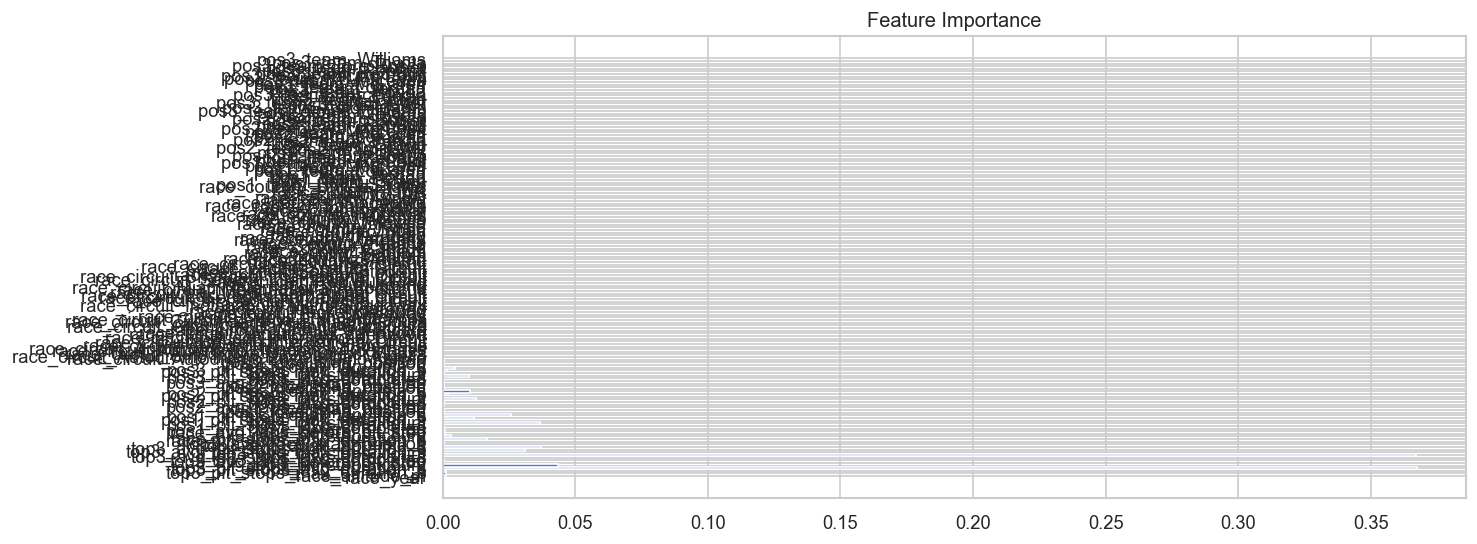

In [98]:
# Feature importance plot
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

The feature importance plot shows that race_pit_stops_min_duration_s is by far the most dominant predictor, contributing the majority of the model’s predictive power. It has an importance value close to 0.9, indicating that the model relies heavily on this variable to predict the average pit stop duration.

The second most important feature is race_pit_stops_max_duration_s, but its contribution is much smaller compared to race_pit_stops_min_duration_s. All other features—including race characteristics (year, round, circuit), location variables (latitude, longitude, altitude), and pit strategy variables (race_pit_stops_count, race_avg_laps_before_pit_stop)—have negligible importance in the model.

### **Lab 2 (HEMANT)**

CLASSIFICATION PROBLEM : Predict whether a driver will finish in the top 3 or not

In [99]:
clf_df = pd.read_csv('f1_driver_classification_data.csv')

print('Classification dataset shape:', clf_df.shape)
print('Top-3 finish rate:', clf_df['top3_finish'].mean().round(3))
display(clf_df.head())


Classification dataset shape: (5970, 17)
Top-3 finish rate: 0.154


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556,0


In [100]:
X = clf_df.drop(columns=['top3_finish'])
y = clf_df['top3_finish']

X = X.dropna()
y = y[X.index]

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
display(X.head())


Features: 16, Samples: 5970


,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556


In [101]:
X = pd.get_dummies(X, columns=['team', 'race_circuit', 'race_country'], drop_first=True)


In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [103]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [104]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [105]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9095477386934674

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95      1011
           1       0.75      0.61      0.67       183

    accuracy                           0.91      1194
   macro avg       0.84      0.79      0.81      1194
weighted avg       0.90      0.91      0.91      1194


Confusion Matrix:
 [[974  37]
 [ 71 112]]


In [106]:
clf_df.columns


Index(['race_year', 'race_circuit', 'race_country', 'race_altitude_m', 'team',
       'race_start_position', 'qualifying_position', 'quali_lap_time_s',
       'laps_completed', 'driver_pit_stops_count',
       'driver_pit_stops_avg_duration_s', 'race_pit_stops_count',
       'race_pit_stops_avg_duration_s', 'race_pit_stops_max_duration_s',
       'race_pit_stops_min_duration_s', 'race_avg_laps_before_pit_stop',
       'top3_finish'],
      dtype='object')

In [107]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9195979899497487


We built a classification model to predict whether a driver finishes in the top 3 using race features and pit stop statistics. The dataset was preprocessed by encoding categorical variables and scaling numerical features. A Logistic Regression model was trained and evaluated using accuracy, classification report, and confusion matrix. Additionally, a Random Forest model was tested to improve performance.

In [108]:
importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

display(feature_importance_df.head(10))


,feature,importance
2,race_start_position,0.210881
3,qualifying_position,0.206410
7,driver_pit_stops_avg_duration_s,0.056472
4,quali_lap_time_s,0.050798
28,team_Mercedes,0.038611
12,race_avg_laps_before_pit_stop,0.035711
11,race_pit_stops_min_duration_s,0.035507
9,race_pit_stops_avg_duration_s,0.034904
10,race_pit_stops_max_duration_s,0.034200
0,race_year,0.033736


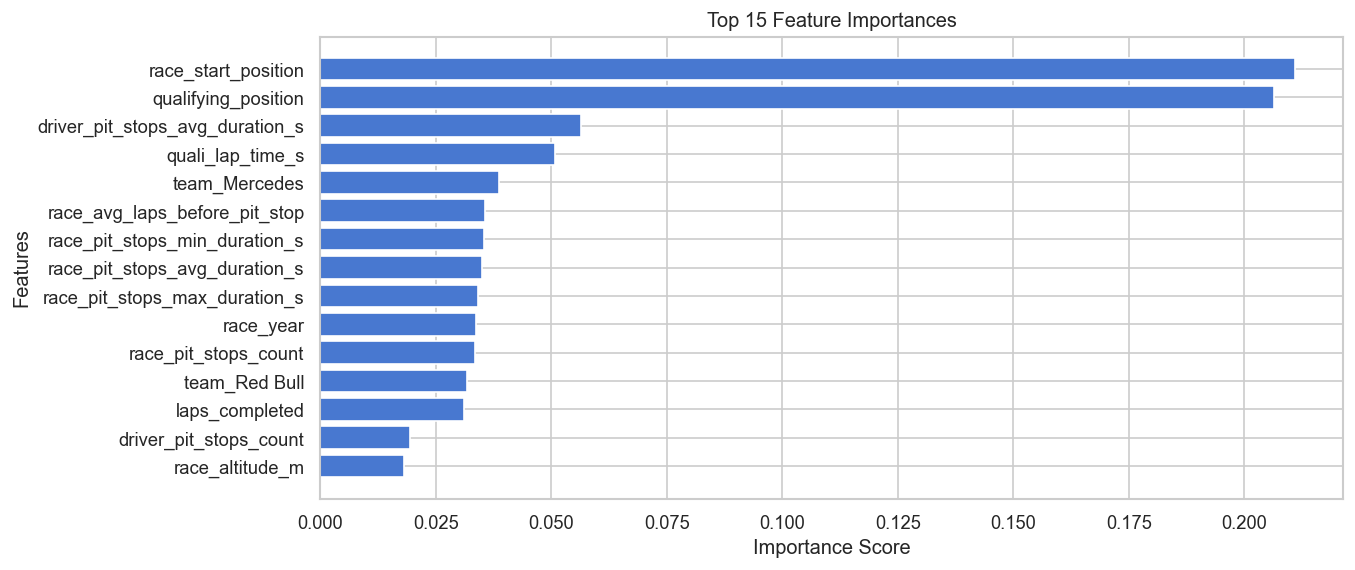

In [109]:
top_features = feature_importance_df.head(15)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


Categorical features (`constructor_name`, `race_circuit`, `race_country`) were one-hot encoded. Since the classification dataset already uses human-readable names, no post-hoc ID mapping is needed.

####**BAGGING**

In [110]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.9170854271356784


####**BOOSTING**

In [111]:
!pip install xgboost

In [112]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.907035175879397


In [113]:
results_df = pd.DataFrame({
    'Model': ['Bagging', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_bag),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results_df

,Model,Accuracy
0,Bagging,0.917085
1,Random Forest,0.919598
2,XGBoost,0.907035


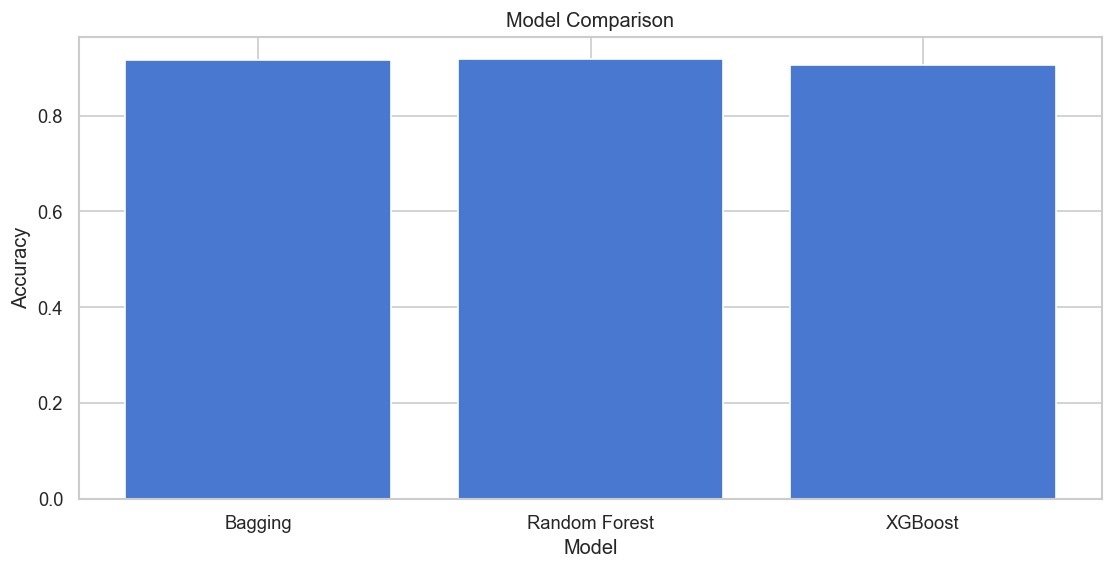

In [114]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

We compared three ensemble methods: Bagging, Random Forest, and XGBoost.
Random Forest improves over Bagging by reducing variance and selecting
important features, while XGBoost further enhances performance through
sequential learning and error correction.

The model with the highest accuracy indicates better predictive performance
for classifying whether a driver finishes in the top 3. Typically, XGBoost
performs best due to its ability to capture complex patterns in the data.